# Attention: causal, multi-head, grouped-query

**The whole idea in one sentence:** every token asks a question, every token offers
a label and a payload, and each token takes a weighted average of the payloads —
weighted by how well each label answers its question.

That's three lines of math. Everything else in this notebook is one restriction and
two pieces of bookkeeping stacked on top of those three lines:

- **causal** — a token may only look backwards *(a restriction)*
- **multi-head** — run several small attentions side by side instead of one big one
  *(bookkeeping)*
- **grouped-query** — let several of those share their labels and payloads, so the
  memory needed to generate text shrinks *(bookkeeping)*

The positional notebooks ([sinusoidal](../positional/sinusoidal.ipynb),
[rope](../positional/rope.ipynb)) were about telling attention *where* things are.
This one is about attention itself.

By the end you'll have:

- computed attention for *dog bites man* by hand, with two-number vectors
- watched softmax **saturate** as vectors get wider, and seen why everyone divides by
  `sqrt(d)`
- trained a model on **random tokens**, where nothing can be predicted, and watched
  the version without a causal mask reach a loss seven times better than is possible
- seen why one head has to *blend* what two heads can keep apart
- split a vector into heads the right way, then the wrong way that has **the right
  shape, no error, and scrambled tokens**
- generated token by token with a KV cache, measured what that cache costs, and cut
  it 8× with grouped-query attention
- shared KV heads in the wrong order — again the right shape, again no error

In [1]:
import math

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
np.set_printoptions(precision=3, suppress=True, linewidth=110)
torch.set_printoptions(precision=3, sci_mode=False, linewidth=110)

try:
    import matplotlib
    import matplotlib.pyplot as plt
    from matplotlib.colors import LinearSegmentedColormap
    HAVE_MPL = True
except ImportError:
    HAVE_MPL = False
    print("matplotlib not installed - plot cells will print a note instead "
          "(uv sync --extra demo)")

SURFACE, INK, INK2, GRID = "#fcfcfb", "#1f1e1d", "#6b6a63", "#e8e7e3"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"

def style(ax):
    ax.set_facecolor(SURFACE)
    ax.grid(color=GRID, lw=0.6)
    ax.tick_params(colors=INK2, labelsize=8)
    for s in ax.spines.values():
        s.set_visible(False)

---
## 1. Three words, by hand

*dog bites man.* Each token carries three small vectors. Give them names that say
what they're for:

- a **query** — the question this token is asking
- a **key** — the label this token advertises to others
- a **value** — the payload it hands over if chosen

Where these come from is section 4. For now, write them down.

In [2]:
words = ["dog", "bites", "man"]
key   = {"dog": [1.0, 0.0], "bites": [0.0, 1.0], "man": [1.0, 1.0]}
value = {"dog": [10.0, 0.0], "bites": [0.0, 10.0], "man": [5.0, 5.0]}
query_man = [1.0, 0.0]            # 'man' is asking: "who here looks like [1, 0]?"

# step 1: score the question against every label (a dot product)
scores = [sum(q * k for q, k in zip(query_man, key[w])) for w in words]

# step 2: turn scores into weights that sum to 1 (softmax)
exps = [math.exp(s) for s in scores]
weights = [e / sum(exps) for e in exps]

# step 3: weighted average of the payloads
out = [sum(wt * value[w][i] for wt, w in zip(weights, words)) for i in range(2)]

for w, s, wt in zip(words, scores, weights):
    print(f"man -> {w:5}   score {s:.0f}   weight {wt:.3f}   payload {value[w]}")
print(f"\nwhat 'man' becomes: [{out[0]:.2f}, {out[1]:.2f}]")

man -> dog     score 1   weight 0.422   payload [10.0, 0.0]
man -> bites   score 0   weight 0.155   payload [0.0, 10.0]
man -> man     score 1   weight 0.422   payload [5.0, 5.0]

what 'man' becomes: [6.33, 3.67]


*Man*'s question matched *dog* and itself equally (score 1), and *bites* not at all
(score 0). So its output is mostly the *dog* and *man* payloads, with a little
*bites* mixed in.

**That's the entire mechanism.** Score, softmax, average. A token's output is a
blend of everyone's payloads, and the blend is decided by how well labels answer
its question.

Notice what softmax did with a score of 0: it still gave *bites* 15% of the weight.
Softmax never says "no", only "less". To say "much less", the scores have to be
further apart. Ask the same question four times louder:

In [3]:
for loudness in (1, 4, 16):
    sc = [loudness * s for s in scores]
    ex = [math.exp(s - max(sc)) for s in sc]
    print(f"query x{loudness:<2}  scores {sc}   weights {[round(e / sum(ex), 3) for e in ex]}")

query x1   scores [1.0, 0.0, 1.0]   weights [0.422, 0.155, 0.422]
query x4   scores [4.0, 0.0, 4.0]   weights [0.495, 0.009, 0.495]
query x16  scores [16.0, 0.0, 16.0]   weights [0.5, 0.0, 0.5]


Bigger scores, sharper attention. At ×16 *bites* is gone entirely and the output is
a clean 50/50 of *dog* and *man*. Hold on to this — **the size of the scores is a
volume knob on how decisive attention is** — because section 3 is about what
happens when that knob gets turned by accident.

---
## 2. Everyone at once

Every token asks its own question, so stack the queries into a matrix, the keys into
a matrix, the values into a matrix, and the three steps become three lines:

In [4]:
def attention(q, k, v):
    scores = q @ k.transpose(-2, -1)          # [tokens, tokens]: every question against every label
    weights = scores.softmax(dim=-1)          # each row sums to 1
    return weights @ v, weights               # each row: that token's blend of payloads

K = torch.tensor([key[w] for w in words])
V = torch.tensor([value[w] for w in words])
Q = torch.tensor([[1.0, 0.0], [0.0, 1.0], [1.0, 0.0]])    # a question per token; man's is the last row

out, W = attention(Q, K, V)
print("weights (row = who is asking, column = who is being looked at):\n", W)
print("\noutputs:\n", out)
print("\nlast row matches the hand trace:", [round(x, 2) for x in out[2].tolist()])

weights (row = who is asking, column = who is being looked at):
 tensor([[0.422, 0.155, 0.422],
        [0.155, 0.422, 0.422],
        [0.422, 0.155, 0.422]])

outputs:
 tensor([[6.335, 3.665],
        [3.665, 6.335],
        [6.335, 3.665]])

last row matches the hand trace: [6.33, 3.67]


Row `i` of the weight matrix is token `i`'s attention pattern. It's a square table,
tokens × tokens, which is where attention's cost comes from: double the sequence,
quadruple the table.

---
## 3. Why everyone divides by `sqrt(d)`

Real queries and keys aren't 2 numbers wide, they're 64 or 128. A dot product is a
sum of `d` products, so **wider vectors make bigger scores** — not because the match
is better, just because there are more terms. And section 1 showed what bigger
scores do.

Measure it. Random queries and keys at increasing width, 16 tokens, and ask: how
much weight does the single favourite key get? With 16 keys and no real signal, the
honest answer is "not much more than 1/16".

In [5]:
def favourite_weight(d, scale):
    g = torch.Generator().manual_seed(0)
    q, k = torch.randn(200, 16, d, generator=g), torch.randn(200, 16, d, generator=g)
    s = q @ k.transpose(-2, -1)
    if scale:
        s = s / math.sqrt(d)
    return s.softmax(-1).max(-1).values.mean().item(), s.std().item()

widths = [2, 8, 32, 128, 512]
print(" width   score spread          favourite key's weight")
print("         raw    / sqrt(d)      raw    / sqrt(d)")
for d in widths:
    (raw_w, raw_s), (sc_w, sc_s) = favourite_weight(d, False), favourite_weight(d, True)
    print(f"{d:>6}  {raw_s:>6.2f}  {sc_s:>6.2f}       {raw_w:>6.2f}  {sc_w:>6.2f}")

 width   score spread          favourite key's weight
         raw    / sqrt(d)      raw    / sqrt(d)
     2    1.43    1.01         0.30    0.23
     8    2.82    1.00         0.57    0.24
    32    5.66    1.00         0.78    0.25
   128   11.30    1.00         0.89    0.25
   512   22.54    1.00         0.95    0.25


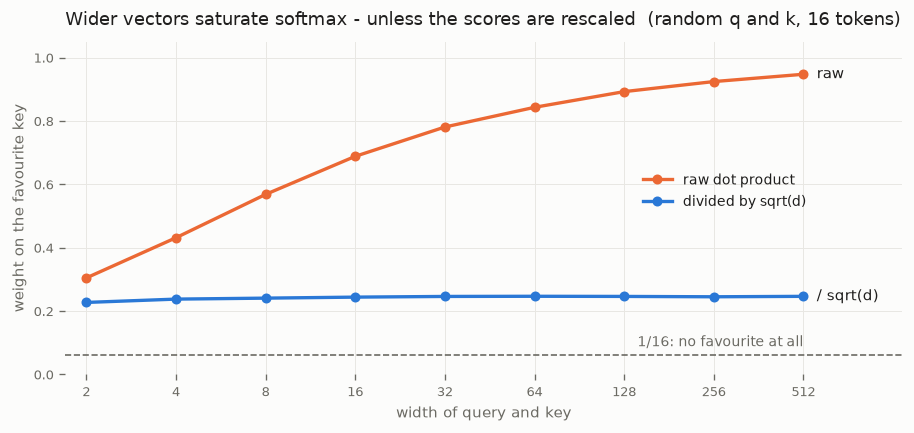

In [6]:
if HAVE_MPL:
    ws = [2, 4, 8, 16, 32, 64, 128, 256, 512]
    raw = [favourite_weight(d, False)[0] for d in ws]
    scaled = [favourite_weight(d, True)[0] for d in ws]
    fig, ax = plt.subplots(figsize=(9, 3.6), dpi=120)
    fig.patch.set_facecolor(SURFACE); style(ax)
    ax.plot(ws, raw, color=ORANGE, lw=2, marker="o", ms=5, label="raw dot product")
    ax.plot(ws, scaled, color=BLUE, lw=2, marker="o", ms=5, label="divided by sqrt(d)")
    ax.axhline(1 / 16, color=INK2, lw=1, ls="--")
    ax.annotate("1/16: no favourite at all", (512, 1 / 16), xytext=(0, 5), textcoords="offset points",
                color=INK2, fontsize=8.5, ha="right")
    ax.annotate("raw", (ws[-1], raw[-1]), xytext=(8, 0), textcoords="offset points", color=INK, fontsize=9, va="center")
    ax.annotate("/ sqrt(d)", (ws[-1], scaled[-1]), xytext=(8, 0), textcoords="offset points", color=INK, fontsize=9, va="center")
    ax.set_xscale("log", base=2); ax.set_xticks(ws); ax.set_xticklabels(ws)
    ax.set_xlim(1.7, 1100); ax.set_ylim(0, 1.05)
    ax.set_title("Wider vectors saturate softmax - unless the scores are rescaled  (random q and k, 16 tokens)",
                 color=INK, fontsize=11, loc="left", pad=10)
    ax.set_xlabel("width of query and key", color=INK2, fontsize=9)
    ax.set_ylabel("weight on the favourite key", color=INK2, fontsize=9)
    ax.legend(loc="center right", bbox_to_anchor=(0.9, 0.55), fontsize=8.5, frameon=False, labelcolor=INK)
    plt.show()
else:
    print("(plot skipped)")

The raw score spread grows like `sqrt(d)`. By width 512 the favourite key takes
essentially **all** the weight, on pure noise — attention has become a hard argmax
before it has learned anything. That's bad for a specific reason: a saturated
softmax has a gradient of almost zero, so the model can barely learn its way out.

Dividing by `sqrt(d)` cancels the growth exactly. The spread stays at 1 and the
favourite's weight stays put at every width. It isn't a trick for accuracy; it's
what keeps the volume knob where you left it when you change the model's width.

Two ways to get this wrong, both silent: forget it, or divide by the wrong `d`. The
`d` is the width of **the vectors being dotted**. Once attention has heads, that's
the head width, not the model width.

In [7]:
def attention(q, k, v):                                        # the real one, from here on
    scores = q @ k.transpose(-2, -1) / math.sqrt(q.shape[-1])
    weights = scores.softmax(dim=-1)
    return weights @ v, weights

---
## 4. Where queries, keys and values come from

Nobody writes them down. Each token has one vector `x` — its embedding, or the
output of the previous layer — and the three roles are **three different learned
views of that same vector**:

```
q = x @ Wq        "given what I am, what am I looking for?"
k = x @ Wk        "given what I am, what do I advertise?"
v = x @ Wv        "given what I am, what do I hand over?"
```

plus a fourth matrix `Wo` applied to the result, so the layer can decide how to
write its findings back. Those four matrices are everything attention learns. The
scoring, the softmax, the averaging have no parameters at all.

This is why it's called *self*-attention: queries, keys and values all come from the
same sequence.

In [8]:
D = 8
x = torch.randn(3, D)                                   # three tokens, each one vector
Wq, Wk, Wv, Wo = (torch.randn(D, D) * 0.5 for _ in range(4))

out, W = attention(x @ Wq.T, x @ Wk.T, x @ Wv.T)
out = out @ Wo.T
print("in :", tuple(x.shape), "  out:", tuple(out.shape), "  <- same shape: a layer you can stack")
print(f"learned numbers: 4 x {D} x {D} = {4 * D * D}")

in : (3, 8)   out: (3, 8)   <- same shape: a layer you can stack
learned numbers: 4 x 8 x 8 = 256


---
## 5. Causal: no looking ahead

A language model is trained to predict the next token. At position `i` its job is to
guess token `i + 1`. If token `i` is allowed to *attend* to token `i + 1`, the
answer is sitting right there in the input.

So position `i` may only see positions `j <= i`. Implement it by overwriting the
forbidden scores with `-inf` before the softmax. `exp(-inf)` is exactly `0`, so those
tokens get exactly zero weight and the rest renormalise among themselves.

In [9]:
def causal_attention(q, k, v):
    s = q.shape[-2]
    scores = q @ k.transpose(-2, -1) / math.sqrt(q.shape[-1])
    allowed = torch.ones(s, s, dtype=torch.bool).tril()          # lower triangle: j <= i
    weights = scores.masked_fill(~allowed, float("-inf")).softmax(dim=-1)
    return weights @ v, weights

S = 6
g = torch.Generator().manual_seed(2)
xs = torch.randn(S, D, generator=g)
_, W_free = attention(xs @ Wq.T, xs @ Wk.T, xs @ Wv.T)
_, W_causal = causal_attention(xs @ Wq.T, xs @ Wk.T, xs @ Wv.T)

print("the mask:\n", torch.ones(S, S, dtype=torch.int).tril())
print("\ncausal weights (each row still sums to 1):\n", W_causal)

the mask:
 tensor([[1, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1, 1]], dtype=torch.int32)

causal weights (each row still sums to 1):
 tensor([[1.000, 0.000, 0.000, 0.000, 0.000, 0.000],
        [0.455, 0.545, 0.000, 0.000, 0.000, 0.000],
        [0.164, 0.813, 0.023, 0.000, 0.000, 0.000],
        [0.092, 0.238, 0.342, 0.329, 0.000, 0.000],
        [0.203, 0.079, 0.165, 0.485, 0.067, 0.000],
        [0.126, 0.238, 0.149, 0.360, 0.016, 0.110]])


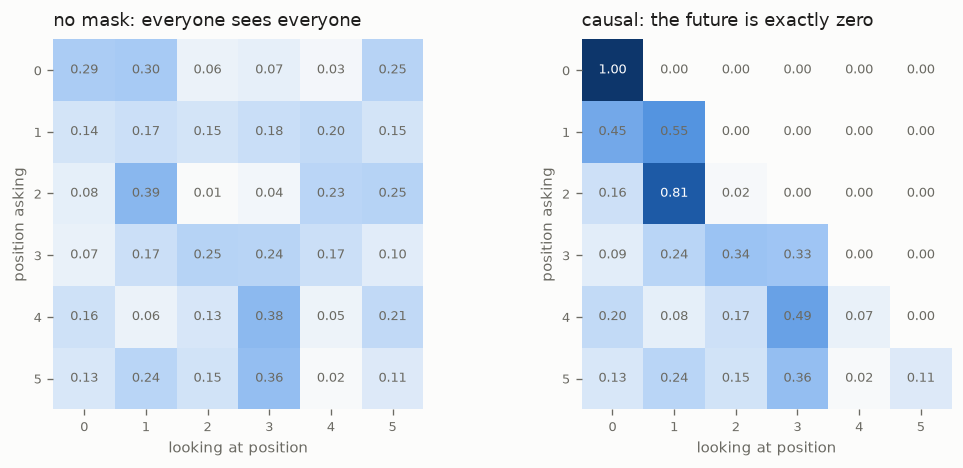

In [10]:
if HAVE_MPL:
    seq = LinearSegmentedColormap.from_list("seq", ["#fcfcfb", "#9ec5f4", "#2a78d6", "#0d366b"])
    fig, axes = plt.subplots(1, 2, figsize=(9, 4), dpi=120)
    fig.patch.set_facecolor(SURFACE)
    for ax, (title, M) in zip(axes, (("no mask: everyone sees everyone", W_free),
                                     ("causal: the future is exactly zero", W_causal))):
        style(ax); ax.grid(False)
        im = ax.imshow(M.numpy(), cmap=seq, vmin=0, vmax=1, interpolation="nearest")
        for i in range(S):
            for j in range(S):
                val = M[i, j].item()
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7.5,
                        color="#ffffff" if val > 0.55 else INK2)
        ax.set_title(title, color=INK, fontsize=10.5, loc="left", pad=8)
        ax.set_xlabel("looking at position", color=INK2, fontsize=9)
        ax.set_ylabel("position asking", color=INK2, fontsize=9)
    fig.tight_layout()
    plt.show()
else:
    print("(plot skipped)")

The first row is always `[1, 0, 0, ...]`: token 0 has nobody to look at but itself,
so its output is just its own payload. The last row is the only one that sees
everything.

One forward pass now produces a valid prediction at *every* position at once, each
made from its own prefix. That's what makes training efficient: a sequence of 1,024
tokens is 1,024 training examples for the price of one pass.

### Break it on purpose: the loss that's too good

Here is the trap, and like the unshifted targets in the preprocessing notebook it
makes things look **better**. Train a small model to predict the next token on
*random* sequences. Random tokens can't be predicted, so the best possible loss is
`ln(vocab)`. Any model doing better than that is cheating.

In [11]:
VOCAB, SEQ, WIDTH = 16, 8, 32

class Toy(nn.Module):
    def __init__(self, causal):
        super().__init__()
        self.causal = causal
        self.tok, self.pos = nn.Embedding(VOCAB, WIDTH), nn.Embedding(SEQ, WIDTH)
        self.q, self.k, self.v = (nn.Linear(WIDTH, WIDTH, bias=False) for _ in range(3))
        self.head = nn.Linear(WIDTH, VOCAB)

    def forward(self, ids):
        x = self.tok(ids) + self.pos(torch.arange(ids.shape[1]))
        fn = causal_attention if self.causal else attention
        mixed, _ = fn(self.q(x), self.k(x), self.v(x))
        return self.head(x + mixed)

def train(causal, steps=1500):
    torch.manual_seed(0)
    model, gen = Toy(causal), torch.Generator().manual_seed(1)
    opt = torch.optim.Adam(model.parameters(), lr=3e-3)
    curve = []
    for step in range(steps):
        seq = torch.randint(0, VOCAB, (64, SEQ + 1), generator=gen)     # fresh random data every step
        loss = F.cross_entropy(model(seq[:, :-1]).reshape(-1, VOCAB), seq[:, 1:].reshape(-1))
        opt.zero_grad(); loss.backward(); opt.step()
        curve.append(loss.item())
    return curve

masked, unmasked = train(causal=True), train(causal=False)
print(f"best possible on random tokens: ln({VOCAB}) = {math.log(VOCAB):.3f}\n")
print(f"with the causal mask:    final loss {np.mean(masked[-50:]):.3f}")
print(f"without the causal mask: final loss {np.mean(unmasked[-50:]):.3f}   <- about seven times better than possible")

best possible on random tokens: ln(16) = 2.773

with the causal mask:    final loss 2.775
without the causal mask: final loss 0.377   <- about seven times better than possible


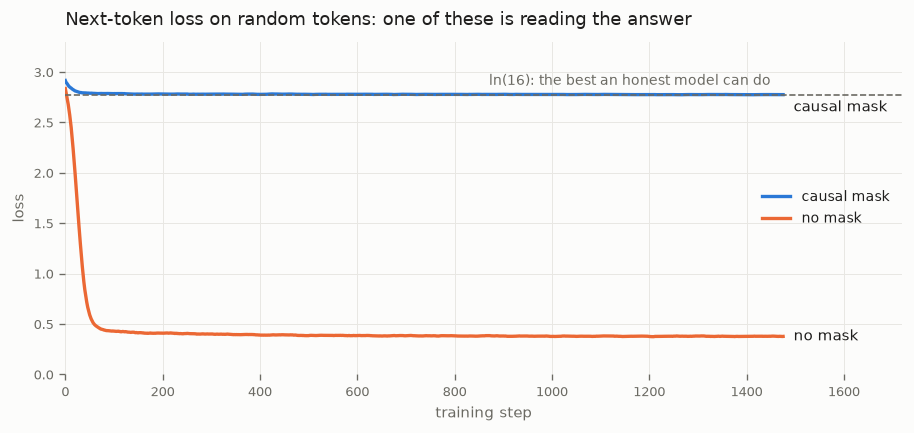

In [12]:
if HAVE_MPL:
    def smooth(c, n=25):
        return np.convolve(c, np.ones(n) / n, mode="valid")
    fig, ax = plt.subplots(figsize=(9, 3.6), dpi=120)
    fig.patch.set_facecolor(SURFACE); style(ax)
    ax.plot(smooth(masked), color=BLUE, lw=2, label="causal mask")
    ax.plot(smooth(unmasked), color=ORANGE, lw=2, label="no mask")
    ax.axhline(math.log(VOCAB), color=INK2, lw=1, ls="--")
    ax.annotate(f"ln({VOCAB}): the best an honest model can do", (1450, math.log(VOCAB)), xytext=(0, 6),
                textcoords="offset points", color=INK2, fontsize=8.5, ha="right")
    ax.annotate("causal mask", (len(smooth(masked)), smooth(masked)[-1]), xytext=(6, -10), textcoords="offset points",
                color=INK, fontsize=9)
    ax.annotate("no mask", (len(smooth(unmasked)), smooth(unmasked)[-1]), xytext=(6, 0), textcoords="offset points",
                color=INK, fontsize=9, va="center")
    ax.set_xlim(0, 1720); ax.set_ylim(0, 3.3)
    ax.set_title("Next-token loss on random tokens: one of these is reading the answer", color=INK, fontsize=11, loc="left", pad=10)
    ax.set_xlabel("training step", color=INK2, fontsize=9); ax.set_ylabel("loss", color=INK2, fontsize=9)
    ax.legend(loc="center right", fontsize=8.5, frameon=False, labelcolor=INK)
    plt.show()
else:
    print("(plot skipped)")

The masked model learns the only thing there is to learn — nothing — and sits at
`ln(16)`. The unmasked model learns "look one position to the right and copy", and
its loss collapses. It lands near `ln(16) / 8` rather than zero only because the
last position in each window has no right-hand neighbour to copy from.

A model that does this looks like the best run you've ever had, right up until you
try to *generate* with it and there is no future to read. This is why the repo's
causality test doesn't inspect the mask — it perturbs a token and demands that
every earlier output stays **bit-identical**:

In [13]:
def leaks(fn, t=3):
    q, k, v = xs @ Wq.T, xs @ Wk.T, xs @ Wv.T
    poked = xs.clone(); poked[t] += 10.0
    before, _ = fn(q, k, v)
    after, _ = fn(poked @ Wq.T, poked @ Wk.T, poked @ Wv.T)
    return not torch.equal(before[:t], after[:t])

print("poke token 3; do tokens 0-2 change?")
print("   no mask    :", leaks(attention))
print("   causal mask:", leaks(causal_attention))

poke token 3; do tokens 0-2 change?
   no mask    : True
   causal mask: False


### Why `-inf` and not "a big negative number"

You'll see `-1e9` used as the fill. In float32 it gives the same exact zeros, because
`exp(-1e9)` underflows. The difference shows up when the mask is **wrong**. Shift it
by one so a token can't see itself, and the first token is left with nothing allowed:

In [14]:
row = torch.tensor([0.3, 1.2, -0.5])            # the first token's scores, all of them forbidden
print("fill -inf:", row.masked_fill(torch.ones(3, dtype=torch.bool), float("-inf")).softmax(-1).tolist())
print("fill -1e9:", row.masked_fill(torch.ones(3, dtype=torch.bool), -1e9).softmax(-1).tolist())

fill -inf: [nan, nan, nan]
fill -1e9: [0.3333333432674408, 0.3333333432674408, 0.3333333432674408]


With `-inf` the row is NaN, the loss is NaN, and you find the bug in the first step.
With `-1e9` the token quietly attends **uniformly to everything it was forbidden to
see**, future included, and training proceeds. `-inf` is the choice that fails loudly.

---
## 6. Multi-head: several questions at once

One attention computes, for each token, **one** weighted average. That's a real
limit. Suppose a token needs two different things from two different places — the
subject of the sentence *and* the verb. One softmax can put half its weight on
each, but then it receives their **blend**:

In [15]:
vA = torch.tensor([1.0, 2.0, 3.0, 4.0])          # payload at position A
vB = torch.tensor([5.0, 6.0, 7.0, 8.0])          # payload at position B

one_head = 0.5 * vA + 0.5 * vB
one_head_swapped = 0.5 * vB + 0.5 * vA            # the two tokens trade places
print("one head, looking at both  :", one_head.tolist())
print("...after A and B swap      :", one_head_swapped.tolist(), " <- identical: which was which is gone")

# two heads, each half as wide: head 0 looks only at A, head 1 looks only at B
two_heads = torch.cat((vA[:2], vB[2:]))
two_heads_swapped = torch.cat((vB[:2], vA[2:]))
print("\ntwo heads, one target each :", two_heads.tolist())
print("...after A and B swap      :", two_heads_swapped.tolist(), " <- different: both survive, separately")

one head, looking at both  : [3.0, 4.0, 5.0, 6.0]
...after A and B swap      : [3.0, 4.0, 5.0, 6.0]  <- identical: which was which is gone

two heads, one target each : [1.0, 2.0, 7.0, 8.0]
...after A and B swap      : [5.0, 6.0, 3.0, 4.0]  <- different: both survive, separately


An average destroys which-was-which. Two heads don't average across each other —
their outputs are laid **side by side** — so each can make a sharp choice of its
own and both choices survive.

**That's the entire trick:** cut the width into `heads` slices, run the three lines
independently on each slice, and concatenate. A head of width 64 inside a model of
width 768 is one of 12 independent attentions, each free to look somewhere else.

What people expect, and it isn't so: **more heads does not mean more parameters.**
The four matrices are the same size either way. Heads are a way of *using* the
width, not adding to it.

### The obviously-correct version

Write it as a loop first, so there's something to check the fast version against.
Head `h` owns channels `h * head_dim` to `(h + 1) * head_dim`:

In [16]:
def mha_loop(x, Wq, Wk, Wv, Wo, heads):
    hd = x.shape[-1] // heads
    q, k, v = x @ Wq.T, x @ Wk.T, x @ Wv.T                         # [b, s, d]
    outs = []
    for h in range(heads):
        sl = slice(h * hd, (h + 1) * hd)                           # this head's channels
        outs.append(causal_attention(q[..., sl], k[..., sl], v[..., sl])[0])
    return torch.cat(outs, dim=-1) @ Wo.T                          # side by side, then mix

B, S, D, HEADS = 2, 6, 16, 4
g = torch.Generator().manual_seed(3)
x = torch.randn(B, S, D, generator=g)
Wq, Wk, Wv, Wo = (torch.randn(D, D, generator=g) * 0.3 for _ in range(4))
ref = mha_loop(x, Wq, Wk, Wv, Wo, HEADS)
print("output:", tuple(ref.shape), f"   parameters: {4 * D * D}, whatever the number of heads")

output: (2, 6, 16)    parameters: 1024, whatever the number of heads


### The version everyone writes

No loop: reshape so that `heads` becomes a batch-like axis, and one matrix multiply
does every head at once. Two moves, and **their order is the whole thing**:

1. `view(b, s, heads, head_dim)` — cut the channel axis into heads. Channels are
   laid out head by head, so this is a pure relabelling.
2. `transpose(1, 2)` — move `heads` next to `batch`, giving `[b, heads, s, head_dim]`,
   so each head sees a `[s, head_dim]` sequence of its own.

On the way out, the mirror image: transpose back, *then* flatten.

In [17]:
def mha(x, Wq, Wk, Wv, Wo, heads, split="right"):
    b, s, d = x.shape
    hd = d // heads
    if split == "right":
        cut = lambda t: t.view(b, s, heads, hd).transpose(1, 2)    # [b, h, s, hd]
    else:
        cut = lambda t: t.view(b, heads, s, hd)                    # same shape. wrong.
    out, _ = causal_attention(cut(x @ Wq.T), cut(x @ Wk.T), cut(x @ Wv.T))
    return out.transpose(1, 2).reshape(b, s, d) @ Wo.T

fast = mha(x, Wq, Wk, Wv, Wo, HEADS)
print("reshape version == loop version:", torch.allclose(fast, ref, atol=1e-5))

reshape version == loop version: True


### Break it on purpose: the right shape, the wrong tokens

Skip the transpose and ask `view` for the final shape directly. It's one call
instead of two, it returns `[b, heads, s, head_dim]` exactly as wanted, and nothing
complains:

In [18]:
wrong = mha(x, Wq, Wk, Wv, Wo, HEADS, split="wrong")
print("shape            :", tuple(wrong.shape), " <- correct")
print("any NaN or inf   :", bool(~torch.isfinite(wrong).all()))
print("matches the loop :", torch.allclose(wrong, ref, atol=1e-5))

def mha_leaks(split, t=3):
    poked = x.clone(); poked[:, t] += 10.0
    a, b_ = mha(x, Wq, Wk, Wv, Wo, HEADS, split), mha(poked, Wq, Wk, Wv, Wo, HEADS, split)
    return not torch.equal(a[:, :t], b_[:, :t])

print("\nleaks the future, right split:", mha_leaks("right"))
print("leaks the future, wrong split:", mha_leaks("wrong"))

shape            : (2, 6, 16)  <- correct
any NaN or inf   : False
matches the loop : False

leaks the future, right split: False
leaks the future, wrong split: True


`view` doesn't move data, it re-reads the same memory with new strides. The memory
is laid out token by token. Asking for `[b, heads, s, hd]` re-reads it as if it were
laid out head by head, so what lands in "head 0, position 2" is really a slice of
some other token. The causal mask is then applied to these scrambled "positions" —
which is why it **also leaks the future**, even though the mask itself is perfect.

This model trains. The loss goes down. It is wrong in a way no shape assertion can
see, which is why the repo checks attention against an independent oracle rather
than against its own shapes.

---
## 7. The cache, and what it costs

Causality has a consequence at generation time. When the model produces token 100,
the keys and values of tokens 0–99 are **exactly what they were** when it produced
token 99 — nothing about the past changes. So you compute each token's key and
value once, keep them, and at every step only compute the *new* token's query, key
and value.

In [19]:
def generate_with_cache(x, Wq, Wk, Wv):
    # single head, one token at a time, remembering every key and value seen so far
    cache_k, cache_v, outs = [], [], []
    for t in range(x.shape[1]):
        xt = x[:, t : t + 1]                                       # only the new token
        cache_k.append(xt @ Wk.T); cache_v.append(xt @ Wv.T)
        K, V = torch.cat(cache_k, dim=1), torch.cat(cache_v, dim=1)
        out, _ = attention(xt @ Wq.T, K, V)                        # no mask needed: the cache IS the past
        outs.append(out)
    return torch.cat(outs, dim=1)

stepwise = generate_with_cache(x, Wq, Wk, Wv)
at_once, _ = causal_attention(x @ Wq.T, x @ Wk.T, x @ Wv.T)
print("token-by-token with a cache == one causal pass:", torch.allclose(stepwise, at_once, atol=1e-5))

token-by-token with a cache == one causal pass: True


That equality — the parallel pass used in training equals the step-by-step pass used
in generation — is the most important property a mixer has, and
`tests/test_state_consistency.py` exists for it.

Now the price. The cache holds one key and one value, per head, per layer, **per
token of context**, and it grows for as long as you generate:

```
bytes per token = 2 (k and v) x layers x kv_heads x head_dim x bytes per number
```

In [20]:
def cache_gb(layers, kv_heads, head_dim, context, bytes_per=2):
    return 2 * layers * kv_heads * head_dim * bytes_per * context / 1e9

# a 70B-shaped decoder: 80 layers, 64 heads of width 128, fp16, one sequence at 32k context
shape = dict(layers=80, head_dim=128, context=32_768)
sizes = {"multi-head (64 KV heads)": cache_gb(kv_heads=64, **shape),
         "grouped-query (8 KV heads)": cache_gb(kv_heads=8, **shape),
         "multi-query (1 KV head)": cache_gb(kv_heads=1, **shape)}
for name, gb in sizes.items():
    print(f"{name:28} {gb:>6.1f} GB of cache, for one sequence")

multi-head (64 KV heads)       85.9 GB of cache, for one sequence
grouped-query (8 KV heads)     10.7 GB of cache, for one sequence
multi-query (1 KV head)         1.3 GB of cache, for one sequence


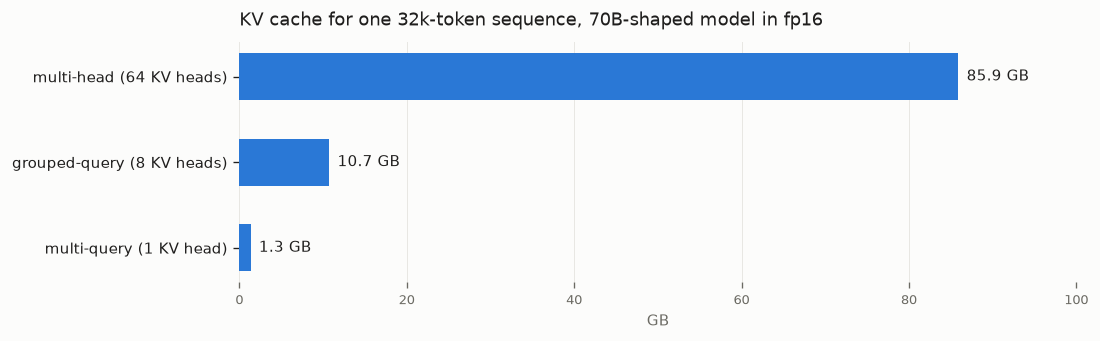

In [21]:
if HAVE_MPL:
    fig, ax = plt.subplots(figsize=(9, 2.6), dpi=120)
    fig.patch.set_facecolor(SURFACE); style(ax); ax.grid(axis="y", visible=False); ax.set_axisbelow(True)
    names, vals = list(sizes), list(sizes.values())
    ax.barh(names[::-1], vals[::-1], color=BLUE, height=0.55)
    for i, v in enumerate(vals[::-1]):
        ax.text(v + 1, i, f"{v:.1f} GB", va="center", color=INK, fontsize=9)
    ax.set_xlim(0, 100)
    ax.set_title("KV cache for one 32k-token sequence, 70B-shaped model in fp16", color=INK, fontsize=11, loc="left", pad=10)
    ax.set_xlabel("GB", color=INK2, fontsize=9)
    ax.tick_params(axis="y", labelsize=9, colors=INK)
    plt.show()
else:
    print("(plot skipped)")

86 GB of cache for *one* sequence — more than the GPU holds, before counting the
weights. At long context the cache, not the model, is what runs out of memory. Every
long-context technique in this repo is, one way or another, an attack on that number.

---
## 8. Grouped-query attention

The cache scales with the number of **key/value** heads. Queries are never cached —
only the newest token's query is ever needed. So: keep all the query heads, and have
them *share* key/value heads.

With 8 query heads and 2 KV heads, query heads 0–3 read KV head 0 and query heads
4–7 read KV head 1. Eight different questions are still being asked. They're being
asked of two sets of labels and payloads instead of eight.

- `kv_heads = heads` is plain **multi-head** attention
- `kv_heads = 1` is **multi-query** attention
- anything between is **grouped-query**

so one function covers all three. In code it's one asymmetry — `Wk` and `Wv` are
smaller — and one line that hands each KV head to its group:

In [22]:
def gqa(x, Wq, Wk, Wv, Wo, heads, kv_heads, expand="interleave"):
    b, s, d = x.shape
    hd, group = d // heads, heads // kv_heads
    q = (x @ Wq.T).view(b, s, heads, hd).transpose(1, 2)           # [b, heads,    s, hd]
    k = (x @ Wk.T).view(b, s, kv_heads, hd).transpose(1, 2)        # [b, kv_heads, s, hd]  <- what gets cached
    v = (x @ Wv.T).view(b, s, kv_heads, hd).transpose(1, 2)
    if expand == "interleave":
        k, v = k.repeat_interleave(group, dim=1), v.repeat_interleave(group, dim=1)
    else:
        k, v = k.repeat(1, group, 1, 1), v.repeat(1, group, 1, 1)
    out, _ = causal_attention(q, k, v)
    return out.transpose(1, 2).reshape(b, s, d) @ Wo.T

B, S, D, HEADS, KV = 2, 6, 32, 8, 2
HD = D // HEADS
g = torch.Generator().manual_seed(4)
x = torch.randn(B, S, D, generator=g)
Wq, Wo = torch.randn(D, D, generator=g) * 0.3, torch.randn(D, D, generator=g) * 0.3
Wk, Wv = torch.randn(KV * HD, D, generator=g) * 0.3, torch.randn(KV * HD, D, generator=g) * 0.3

print(f"Wq {tuple(Wq.shape)}   Wk {tuple(Wk.shape)}   Wv {tuple(Wv.shape)}   <- keys and values are {HEADS // KV}x narrower")
print("output:", tuple(gqa(x, Wq, Wk, Wv, Wo, HEADS, KV).shape))

Wq (32, 32)   Wk (8, 32)   Wv (8, 32)   <- keys and values are 4x narrower
output: (2, 6, 32)


Check it against PyTorch's fused attention, which has its own grouped-query mode and
so checks the grouping independently rather than mirroring ours. And confirm the two
ends of the dial: with `kv_heads = heads` it must be section 6's multi-head, exactly.

In [23]:
q = (x @ Wq.T).view(B, S, HEADS, HD).transpose(1, 2)
k = (x @ Wk.T).view(B, S, KV, HD).transpose(1, 2)
v = (x @ Wv.T).view(B, S, KV, HD).transpose(1, 2)
oracle = F.scaled_dot_product_attention(q, k, v, is_causal=True, enable_gqa=True)
oracle = oracle.transpose(1, 2).reshape(B, S, D) @ Wo.T
print("grouped-query == PyTorch's fused attention:", torch.allclose(gqa(x, Wq, Wk, Wv, Wo, HEADS, KV), oracle, atol=1e-5))

Wk_full, Wv_full = torch.randn(D, D, generator=g) * 0.3, torch.randn(D, D, generator=g) * 0.3
print("kv_heads = heads   == multi-head:          ",
      torch.allclose(gqa(x, Wq, Wk_full, Wv_full, Wo, HEADS, HEADS), mha(x, Wq, Wk_full, Wv_full, Wo, HEADS), atol=1e-5))

grouped-query == PyTorch's fused attention: True
kv_heads = heads   == multi-head:           True


### Break it on purpose: which head reads which

"Copy each KV head `group` times" can be done two ways, and both give
`[b, heads, s, hd]`:

In [24]:
ids = torch.arange(KV)
print("query head:        ", list(range(HEADS)))
print("repeat_interleave: ", ids.repeat_interleave(HEADS // KV).tolist(), " <- heads 0-3 share KV head 0")
print("repeat:            ", ids.repeat(HEADS // KV).tolist(), " <- heads 0,2,4,6 share KV head 0")

a = gqa(x, Wq, Wk, Wv, Wo, HEADS, KV, expand="interleave")
b_ = gqa(x, Wq, Wk, Wv, Wo, HEADS, KV, expand="tile")
print("\nsame shape:", a.shape == b_.shape, "  same numbers:", torch.allclose(a, b_, atol=1e-5),
      "  tiled version matches the oracle:", torch.allclose(b_, oracle, atol=1e-5))

query head:         [0, 1, 2, 3, 4, 5, 6, 7]
repeat_interleave:  [0, 0, 0, 0, 1, 1, 1, 1]  <- heads 0-3 share KV head 0
repeat:             [0, 1, 0, 1, 0, 1, 0, 1]  <- heads 0,2,4,6 share KV head 0

same shape: True   same numbers: False   tiled version matches the oracle: False


Neither is more correct in the abstract — a model trained from scratch with either
would be fine. But **trained weights assume one of them**, and every published
grouped-query checkpoint (and PyTorch's fused kernel) uses the interleaved grouping.
Load those weights into the tiled version and every query head past the first is
reading the wrong keys. Same family of bug as the RoPE layouts: right shape, no
error, wrong answer.

What does sharing cost in quality? Less than you'd expect: the grouped-query paper
found that a handful of KV heads recovers nearly all of multi-head's quality, while
a single KV head gives up a noticeable amount. That's why most current models sit
at around 8 KV heads rather than at either extreme.

---
## 9. The packaged version

`litterbox.model.mixers.reference.full_attention.FullAttention` is section 8 with
`nn.Linear` for the four matrices. Load this notebook's weights into it and it must
produce this notebook's numbers:

In [25]:
from litterbox.model import get_mixer
from litterbox.positional import RoPE

FullAttention = get_mixer("full_attention")             # resolved by name, the way a config does it
layer = FullAttention(d_model=D, heads=HEADS, kv_heads=KV)
with torch.no_grad():
    for proj, W in ((layer.q_proj, Wq), (layer.k_proj, Wk), (layer.v_proj, Wv), (layer.o_proj, Wo)):
        proj.weight.copy_(W)

out, state = layer(x)
print("same numbers as ours:", torch.allclose(out, gqa(x, Wq, Wk, Wv, Wo, HEADS, KV), atol=1e-5))

print("\ncache bytes per token, per layer (fp32):")
for kv in (8, 2, 1):
    print(f"   kv_heads={kv}:  {FullAttention(D, HEADS, kv).state_bytes_per_token:>5.0f}")

same numbers as ours: True

cache bytes per token, per layer (fp32):
   kv_heads=8:    256
   kv_heads=2:     64
   kv_heads=1:     32


Position is **injected**, not built in. The layer calls the strategy's `rotate` hook
on its queries and keys and never asks what it was given — RoPE acts there, NoPE
passes through. With RoPE the scores depend only on distance and the values carry no
position, so the entire layer gives the same output wherever the sequence sits:

In [26]:
roped = FullAttention(D, HEADS, KV, pos=RoPE(HD, max_seq_len=256, layout="half"))
here, _ = roped(x, pos_offset=0)
there, _ = roped(x, pos_offset=200)
print("output at offset 0 == output at offset 200:", torch.allclose(here, there, atol=1e-5))

try:
    from litterbox.model import MixerState
    layer(x[:, :1], state=MixerState())
except NotImplementedError as e:
    print("\nthe cache from section 7 is not packaged yet:\n  ", e)

output at offset 0 == output at offset 200: True

the cache from section 7 is not packaged yet:
   Incremental decode needs the KV cache from infer/cache.py (ROADMAP step 3). The training path, state=None, is complete.


---
## What to remember

| what | why |
|---|---|
| score, softmax, average | the whole mechanism; the four projection matrices are all it learns |
| divide by `sqrt(head_dim)` | wider vectors make bigger scores; unscaled softmax saturates and stops learning |
| mask the future with `-inf` | a next-token model that can see the next token will read it |
| heads: `view` **then** `transpose` | `view` straight to the final shape is legal, silent, and scrambles tokens |
| heads don't add parameters | they split the width so several sharp choices survive side by side |
| the cache scales with KV heads | which is the one thing grouped-query attention shrinks |
| `repeat_interleave`, not `repeat` | the grouping is a convention trained weights depend on |

Four traps in this notebook, and **three of them have the right shape and raise
nothing.** The checks that catch them are never shape checks: a loss floor you
can't beat honestly, a perturbation that must not travel backwards, and an
independent oracle.

---

## Exercises

1. **A fourth word.** Add *hard* to the sentence in section 1 with a key, a value and
   a query of your choosing. Compute its causal attention output by hand, then check
   it with `causal_attention`.
2. **Find the saturation point.** In section 3, use the *unscaled* scores and find
   the width at which the favourite key first takes more than 90% of the weight.
   Then measure the gradient of the output with respect to the scores there.
3. **Make the cheater honest.** In section 5, keep the mask off but shift the
   targets by *two* instead of one. Does it still cheat? What about with the mask
   on — what loss should that reach, and why?
4. **A window instead of a triangle.** Change the mask so position `i` sees only the
   last 3 positions. Verify with the perturbation test that poking token 0 no longer
   reaches token 5. That's `sliding_window`, the next mixer on the roadmap — and
   think about what happens with two such layers stacked.
5. **Convert a checkpoint.** Take multi-head `Wk`, `Wv` with 8 heads and produce
   2-KV-head versions by averaging each group of 4 heads' rows (this is how the
   grouped-query paper initialises from an existing model). How far does the output
   move? What would you do next to close the gap?
6. **Make it real.** Extend `generate_with_cache` to grouped-query heads and confirm
   the cached tensors are `kv_heads` wide, not `heads` wide. Then do it in the repo:
   a `KVCache` in `infer/cache.py`, and the `state is not None` branch of
   `FullAttention.forward`. Two things change — keys and values are appended to the
   cache, and the mask widens from `[s, s]` to `[s, past + s]`. The test that tells
   you it's right already exists: `tests/test_state_consistency.py`.